# Домен: Фінанси (S&P 500)
Цільова змінна: ціна індексу / логарифмічні прибутки. Горизонт прогнозу: 1 торговий день.
Ключова метрика: Directional Accuracy (DA) та MAPE.

## 1. Завантаження даних та EDA

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. Завантаження даних
# Беремо період з 2015 року для достатньої кількості даних для LSTM
ticker = '^GSPC'
data = yf.download(ticker, start='2015-01-01', end='2024-01-01')

# Виправляємо можливий MultiIndex у колонках
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Залишаємо ціну закриття
df_finance = data[['Close']].copy()
df_finance.columns = ['price']

# 2. Розрахунок логарифмічних прибутків (Log Returns)
# Логарифмування допомагає стабілізувати дисперсію
df_finance['log_return'] = np.log(df_finance['price'] / df_finance['price'].shift(1))

# Видаляємо перший рядок з NaN
df_finance.dropna(inplace=True)

print(f"Дані завантажено. Кількість торгових днів: {len(df_finance)}")
print(df_finance.head())

/tmp/ipykernel_55/321654848.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Дані завантажено. Кількість торгових днів: 2263
                  price  log_return
Date                               
2015-01-05  2020.579956   -0.018447
2015-01-06  2002.609985   -0.008933
2015-01-07  2025.900024    0.011563
2015-01-08  2062.139893    0.017730
2015-01-09  2044.810059   -0.008439


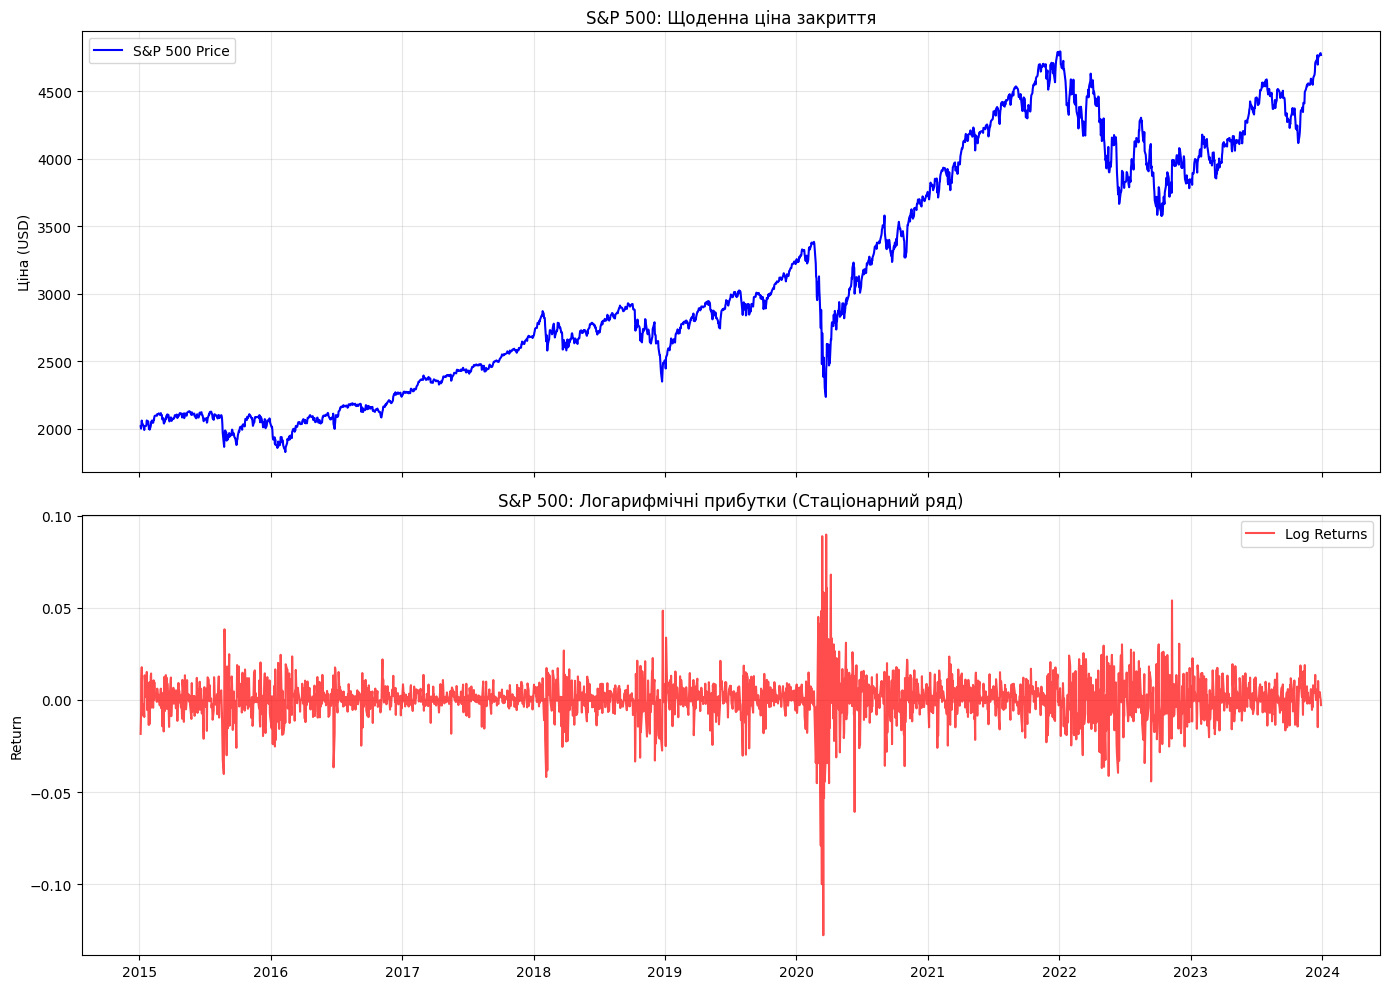

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Графік ціни
ax[0].plot(df_finance.index, df_finance['price'], color='blue', label='S&P 500 Price')
ax[0].set_title('S&P 500: Щоденна ціна закриття')
ax[0].set_ylabel('Ціна (USD)')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Графік логарифмічних прибутків
ax[1].plot(df_finance.index, df_finance['log_return'], color='red', label='Log Returns', alpha=0.7)
ax[1].set_title('S&P 500: Логарифмічні прибутки (Стаціонарний ряд)')
ax[1].set_ylabel('Return')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [9]:
def check_stationarity(series, name):
    print(f"\n--- Тест ADF для: {name} ---")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4e}')
    if result[1] <= 0.05:
        print("Висновок: Ряд стаціонарний (H0 відхилено)")
    else:
        print("Висновок: Ряд НЕ стаціонарний (H0 не відхилено)")

check_stationarity(df_finance['price'], "Ціна (Price)")
check_stationarity(df_finance['log_return'], "Логарифмічні прибутки (Log Returns)")


--- Тест ADF для: Ціна (Price) ---
ADF Statistic: -0.4170
p-value: 9.0722e-01
Висновок: Ряд НЕ стаціонарний (H0 не відхилено)

--- Тест ADF для: Логарифмічні прибутки (Log Returns) ---
ADF Statistic: -14.8159
p-value: 1.9973e-27
Висновок: Ряд стаціонарний (H0 відхилено)


## 2. Базові моделі (Baselines)

In [10]:
from sklearn.metrics import mean_absolute_error

test_size = 252
train_data = df_finance.iloc[:-test_size]
test_data = df_finance.iloc[-test_size:].copy()

# 1. Naive Forecast: завтра = сьогодні (t-1)
test_data['naive_pred'] = df_finance['price'].shift(1).iloc[-test_size:].values

# 2. Seasonal Naive: завтра = цей же день минулого тижня (t-5)
test_data['s_naive_pred'] = df_finance['price'].shift(5).iloc[-test_size:].values

def get_mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100

print(f"Naive MAPE: {get_mape(test_data['price'], test_data['naive_pred']):.2f}%")
print(f"Seasonal Naive MAPE: {get_mape(test_data['price'], test_data['s_naive_pred']):.2f}%")

Naive MAPE: 0.65%
Seasonal Naive MAPE: 1.48%


## 3. Етап 1: Моделі з базовими конфігураціями

### 3.1. Класичні статистичні моделі (ARIMA, SARIMA, Holt-Winters)

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings('ignore')

history = list(train_data['price'].values)
test_values = test_data['price'].values
preds_stats = {'ARIMA': [], 'SARIMA': [], 'HW': []}

print("Запуск статистичних моделей (це займе кілька хвилин)...")

for t in range(len(test_values)):
    # 3. ARIMA(1,0,1) -- ARMA, d=0 (ряд прибутків стаціонарний)
    m_arima = ARIMA(history, order=(1,0,1)).fit()
    preds_stats['ARIMA'].append(m_arima.forecast()[0])
    
    # 4. SARIMA(1,0,1)(1,0,1,5) -- ARMA + сезонність, d=0
    m_sarima = SARIMAX(history, order=(1,0,1), seasonal_order=(1,0,1,5)).fit(disp=False)
    preds_stats['SARIMA'].append(m_sarima.forecast()[0])
    
    # 5. Holt-Winters (адитивна сезонність 5 днів)
    m_hw = ExponentialSmoothing(history, trend='add', seasonal='add', seasonal_periods=5).fit(optimized=True)
    preds_stats['HW'].append(m_hw.forecast()[0])
    
    history.append(test_values[t])

print("Статистичне моделювання завершено.")

Запуск статистичних моделей (це займе кілька хвилин)...
Статистичне моделювання завершено.


In [13]:
from sklearn.metrics import mean_absolute_error

# Функція для розрахунку та виводу
def print_stat_results(name, predictions):
    true_vals = test_data['price'].values
    mae = mean_absolute_error(true_vals, predictions)
    mape = np.mean(np.abs((true_vals - predictions) / true_vals)) * 100
    print(f"{name:<15} | MAPE: {mape:5.2f}% | MAE: {mae:7.2f} USD")

print("--- РЕЗУЛЬТАТИ СТАТИСТИЧНИХ МОДЕЛЕЙ (S&P 500) ---")
# Виводимо базові для порівняння
print_stat_results("Naive (t-1)", test_data['naive_pred'])
print_stat_results("S. Naive (t-5)", test_data['s_naive_pred'])
print("-" * 45)

# Виводимо результати з вашого словника preds_stats
for model_name, p in preds_stats.items():
    print_stat_results(model_name, np.array(p))

--- РЕЗУЛЬТАТИ СТАТИСТИЧНИХ МОДЕЛЕЙ (S&P 500) ---
Naive (t-1)     | MAPE:  0.65% | MAE:   27.47 USD
S. Naive (t-5)  | MAPE:  1.48% | MAE:   63.24 USD
---------------------------------------------
ARIMA           | MAPE:  0.66% | MAE:   28.05 USD
SARIMA          | MAPE:  0.66% | MAE:   27.97 USD
HW              | MAPE:  0.66% | MAE:   27.86 USD


### 3.2. Підготовка даних для ML/DL (Feature Engineering: цінові лаги)

In [14]:
from sklearn.preprocessing import MinMaxScaler

# 1. Параметр вікна (аналогічно 20 торговим дням місяця)
lookback = 20

def create_features(df, window):
    data = df.copy()
    for i in range(1, window + 1):
        data[f'lag_{i}'] = data['price'].shift(i)
    data.dropna(inplace=True)
    return data

# Створюємо набір даних з ознаками
df_ml = create_features(df_finance, lookback)

# Визначаємо цільову змінну (Close Price) та ознаки (Lags)
X = df_ml.drop(['price', 'log_return'], axis=1).values
y = df_ml['price'].values

# Розділяємо на Train та Test (останній рік - 252 дні)
train_idx = len(df_ml) - 252
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

# Ініціалізація та застосування масштабування
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Важливо: fit робимо тільки на Train, transform - на Test
X_train_s = scaler_x.fit_transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))

# Формуємо 3D-тензори для CNN та LSTM (samples, timesteps, features)
X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_test_3d = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

print(f"Підготовку завершено. Розмір X_train_s: {X_train_s.shape}")

Підготовку завершено. Розмір X_train_s: (1991, 20)


### 3.3. XGBoost та SVR

In [15]:
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import numpy as np

print("Навчання XGBoost та SVR для S&P 500...")

# 6. XGBoost
# n_estimators=100 та невеликий learning_rate, щоб не дати моделі занадто швидко "зазубрити" шум
model_xgb_fin = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb_fin.fit(X_train_s, y_train_s)
xgb_p = scaler_y.inverse_transform(model_xgb_fin.predict(X_test_s).reshape(-1, 1))

# 7. Support Vector Regression (SVR)
# rbf - радіально-базисна функція, яка добре вловлює нелінійні зв'язки
model_svr_fin = SVR(kernel='rbf', C=1.0, gamma='scale')
model_svr_fin.fit(X_train_s, y_train_s.ravel())
svr_p = scaler_y.inverse_transform(model_svr_fin.predict(X_test_s).reshape(-1, 1))

def print_ml_metrics(name, preds):
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test - preds.flatten()) / y_test)) * 100
    print(f"{name:<10} | MAPE: {mape:5.2f}% | MAE: {mae:7.2f} USD")

print("\n--- РЕЗУЛЬТАТИ ML (ФІНАНСИ) ---")
print_ml_metrics("XGBoost", xgb_p)
print_ml_metrics("SVR", svr_p)

Навчання XGBoost та SVR для S&P 500...

--- РЕЗУЛЬТАТИ ML (ФІНАНСИ) ---
XGBoost    | MAPE:  0.79% | MAE:   33.77 USD
SVR        | MAPE:  2.39% | MAE:  104.00 USD


### 3.4. Нейронні мережі (MLP, LSTM, 1D-CNN)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Функція для створення свіжого EarlyStopping для кожної моделі
def get_fresh_es():
    return EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    )

# 8. Багатошаровий перцептрон (MLP)
print("Навчання MLP...")
m_mlp = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
m_mlp.compile(optimizer='adam', loss='mse')
m_mlp.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_split=0.1, callbacks=[get_fresh_es()], verbose=0)
mlp_p = scaler_y.inverse_transform(m_mlp.predict(X_test_s, verbose=0))

# 9. Рекурентна мережа (LSTM)
print("Навчання LSTM...")
m_lstm = Sequential([
    Input(shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    LSTM(50, activation='relu'),
    Dropout(0.2), # Dropout допомагає зменшити перенавчання на шумі
    Dense(1)
])
m_lstm.compile(optimizer='adam', loss='mse')
m_lstm.fit(X_train_3d, y_train_s, epochs=100, batch_size=32, validation_split=0.1, callbacks=[get_fresh_es()], verbose=0)
lstm_p = scaler_y.inverse_transform(m_lstm.predict(X_test_3d, verbose=0))

# 10. Згорткова мережа (1D-CNN)
print("Навчання 1D-CNN...")
m_cnn = Sequential([
    Input(shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Conv1D(filters=32, kernel_size=1, activation='relu'), # kernel_size=1 через специфіку 3D-тензора
    Flatten(),
    Dense(1)
])
m_cnn.compile(optimizer='adam', loss='mse')
m_cnn.fit(X_train_3d, y_train_s, epochs=100, batch_size=32, validation_split=0.1, callbacks=[get_fresh_es()], verbose=0)
cnn_p = scaler_y.inverse_transform(m_cnn.predict(X_test_3d, verbose=0))

# Функція для швидкої перевірки MAPE
def quick_mape(name, p):
    val = np.mean(np.abs((y_test - p.flatten()) / y_test)) * 100
    print(f"{name:<10} | MAPE: {val:5.2f}%")

print("\n--- РЕЗУЛЬТАТИ DEEP LEARNING (ФІНАНСИ) ---")
quick_mape("MLP", mlp_p)
quick_mape("LSTM", lstm_p)
quick_mape("1D-CNN", cnn_p)

2026-03-23 13:15:10.430197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774271710.877813      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774271710.997022      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774271712.050834      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774271712.050874      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774271712.050876      55 computation_placer.cc:177] computation placer alr

Навчання MLP...


I0000 00:00:1774271747.813055      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774271747.815831      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1774271750.538063     147 service.cc:152] XLA service 0x7e68140097b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774271750.538095     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774271750.538099     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774271750.846534     147 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774271751.781798     147 device_compiler.h:188] Compiled clust

Epoch 76: early stopping
Restoring model weights from the end of the best epoch: 66.
Навчання LSTM...
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 12.
Навчання 1D-CNN...
Restoring model weights from the end of the best epoch: 98.

--- РЕЗУЛЬТАТИ DEEP LEARNING (ФІНАНСИ) ---
MLP        | MAPE:  0.77%
LSTM       | MAPE:  2.08%
1D-CNN     | MAPE:  0.73%


## 4. Експерименти з Feature Engineering
Дослідження впливу різних наборів ознак на якість прогнозу.

### 4.1. Експеримент: цінові лаги + волатильність + імпульс

In [11]:
# 1. Створення вікна (Lookback window)
lookback = 20

def create_finance_features(df, window):
    data = df.copy()
    # Створюємо лаги (минулі ціни)
    for i in range(1, window + 1):
        data[f'lag_{i}'] = data['price'].shift(i)
    
    # Додаємо волатильність (шум)
    data['volatility_5d'] = data['log_return'].rolling(window=5).std()
    
    # Додаємо імпульс (напрямок)
    data['momentum_5d'] = data['price'] - data['price'].shift(5)
    
    data.dropna(inplace=True)
    return data

df_engineered = create_finance_features(df_finance, lookback)

# 2. Підготовка X та y (прогнозуємо ціну на завтра)
X = df_engineered.drop(['price', 'log_return'], axis=1).values
y = df_engineered['price'].values

# 3. Розділення на Train/Test (без перемішування!)
train_idx = len(df_engineered) - 252
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

# 4. Масштабування (MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

print(f"Матриці готові. Форма X_train: {X_train_scaled.shape}")

Матриці готові. Форма X_train: (1991, 22)


### 4.2. Експеримент: прогноз через логарифмічні прибутки (Log Returns)

In [17]:
from sklearn.preprocessing import StandardScaler

# 1. Створення ознак на основі прибутків
def create_return_features(df, window):
    data = df.copy()
    for i in range(1, window + 1):
        data[f'ret_lag_{i}'] = data['log_return'].shift(i)
    data.dropna(inplace=True)
    return data

df_returns = create_return_features(df_finance, 20)

# Визначаємо X (лаги прибутків) та y (прибуток сьогодні для прогнозу на завтра)
X_ret = df_returns.drop(['price', 'log_return'], axis=1, errors='ignore').values
y_ret = df_returns['log_return'].values

# Розділяємо на Train/Test (252 дні)
train_idx = len(df_returns) - 252
X_train_ret, X_test_ret = X_ret[:train_idx], X_ret[train_idx:]
y_train_ret, y_test_ret = y_ret[:train_idx], y_ret[train_idx:]

# Масштабування (StandardScaler кращий для returns)
scaler_x_ret = StandardScaler()
scaler_y_ret = StandardScaler()

X_train_ret_s = scaler_x_ret.fit_transform(X_train_ret)
X_test_ret_s = scaler_x_ret.transform(X_test_ret)
y_train_ret_s = scaler_y_ret.fit_transform(y_train_ret.reshape(-1, 1))

# Підготовка 3D для LSTM/CNN
X_train_ret_3d = X_train_ret_s.reshape((X_train_ret_s.shape[0], 1, X_train_ret_s.shape[1]))
X_test_ret_3d = X_test_ret_s.reshape((X_test_ret_s.shape[0], 1, X_test_ret_s.shape[1]))

print(f"Дані прибутків готові. Форма: {X_train_ret_s.shape}")

Дані прибутків готові. Форма: (1991, 20)


In [18]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Функція для відновлення ціни з лог-прибутку: P_t+1 = P_t * exp(return)
def reconstruct_price(predicted_returns, current_prices):
    return current_prices * np.exp(predicted_returns.flatten())

# 1. XGBoost на прибутках
model_xgb_ret = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
model_xgb_ret.fit(X_train_ret_s, y_train_ret_s)
xgb_ret_pred_s = model_xgb_ret.predict(X_test_ret_s)
xgb_ret_final = scaler_y_ret.inverse_transform(xgb_ret_pred_s.reshape(-1, 1))

# 2. LSTM на прибутках
model_lstm_ret = Sequential([
    Input(shape=(1, 20)),
    LSTM(32, activation='tanh'), # tanh краще для прибутків (мають від'ємні значення)
    Dropout(0.2),
    Dense(1)
])
model_lstm_ret.compile(optimizer='adam', loss='mse')
model_lstm_ret.fit(X_train_ret_3d, y_train_ret_s, epochs=50, batch_size=32, 
                   validation_split=0.1, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)

lstm_ret_pred_s = model_lstm_ret.predict(X_test_ret_3d, verbose=0)
lstm_ret_final = scaler_y_ret.inverse_transform(lstm_ret_pred_s)

# --- ВІДНОВЛЕННЯ ЦІН ТА РОЗРАХУНОК MAPE ---
# Потрібні ціни за (t-1) для кожного дня тесту
last_prices = df_finance['price'].shift(1).iloc[-252:].values
actual_prices = df_finance['price'].iloc[-252:].values

xgb_price_pred = reconstruct_price(xgb_ret_final, last_prices)
lstm_price_pred = reconstruct_price(lstm_ret_final, last_prices)

def final_compare(name, pred):
    mape = np.mean(np.abs((actual_prices - pred) / actual_prices)) * 100
    print(f"{name:<20} | MAPE (відновлена ціна): {mape:5.2f}%")

print("\n--- ПОРІВНЯННЯ ПІСЛЯ ТРАНСФОРМАЦІЇ ПРИБУТКІВ ---")
print(f"{'Naive Baseline':<20} | MAPE: 0.65%")
final_compare("XGBoost (Returns)", xgb_price_pred)
final_compare("LSTM (Returns)", lstm_price_pred)


--- ПОРІВНЯННЯ ПІСЛЯ ТРАНСФОРМАЦІЇ ПРИБУТКІВ ---
Naive Baseline       | MAPE: 0.65%
XGBoost (Returns)    | MAPE (відновлена ціна):  0.67%
LSTM (Returns)       | MAPE (відновлена ціна):  0.64%


In [19]:
def directional_accuracy(actual_ret, pred_ret):
    # Порівнюємо знаки фактичного та прогнозованого прибутку
    actual_sign = np.sign(actual_ret)
    pred_sign = np.sign(pred_ret)
    accuracy = np.mean(actual_sign == pred_sign) * 100
    return accuracy

print("--- DIRECTIONAL ACCURACY (Влучність напрямку) ---")
# y_test_ret - це фактичні прибутки на тестовій вибірці
print(f"XGBoost DA: {directional_accuracy(y_test_ret, xgb_ret_final.flatten()):.2f}%")
print(f"LSTM DA:    {directional_accuracy(y_test_ret, lstm_ret_final.flatten()):.2f}%")

--- DIRECTIONAL ACCURACY (Влучність напрямку) ---
XGBoost DA: 52.78%
LSTM DA:    52.78%


### 4.3. Експеримент: збагачення технічними індикаторами (RSI, SMA, Volatility)

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def add_technical_indicators(df):
    data = df.copy()
    
    # 1. RSI (Relative Strength Index)
    delta = data['price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    # 2. Moving Average Convergence (Momentum)
    data['sma_5'] = data['price'].rolling(window=5).mean()
    data['sma_20'] = data['price'].rolling(window=20).mean()
    data['sma_ratio'] = data['sma_5'] / data['sma_20']
    
    # 3. Daily Volatility (5 days)
    data['volatility'] = data['log_return'].rolling(window=5).std()
    
    data.dropna(inplace=True)
    return data

df_enriched = add_technical_indicators(df_finance)

# Створюємо ознаки: Лаги прибутків (20) + нові індикатори
lookback = 20
for i in range(1, lookback + 1):
    df_enriched[f'ret_lag_{i}'] = df_enriched['log_return'].shift(i)

df_enriched.dropna(inplace=True)

# Формуємо X (індикатори + лаги) та y (прибуток)
features = [f'ret_lag_{i}' for i in range(1, lookback + 1)] + ['rsi', 'sma_ratio', 'volatility']
X_en = df_enriched[features].values
y_en = df_enriched['log_return'].values

# Розділ на Train/Test (252 дні)
train_idx_en = len(df_enriched) - 252
X_train_en, X_test_en = X_en[:train_idx_en], X_en[train_idx_en:]
y_train_en, y_test_en = y_en[:train_idx_en], y_en[train_idx_en:]

# Масштабування
scaler_en = StandardScaler()
X_train_en_s = scaler_en.fit_transform(X_train_en)
X_test_en_s = scaler_en.transform(X_test_en)

# Формування 3D-тензора для LSTM
X_train_en_3d = X_train_en_s.reshape((X_train_en_s.shape[0], 1, X_train_en_s.shape[1]))
X_test_en_3d = X_test_en_s.reshape((X_test_en_s.shape[0], 1, X_test_en_s.shape[1]))

print(f"Дані збагачено індикаторами. Кількість ознак: {len(features)}")

Дані збагачено індикаторами. Кількість ознак: 23


## 5. Етап 2: Оптимізація моделей
Покращені версії з Dropout, регуляризацією та тюнінгом гіперпараметрів.

### 5.1. LSTM v2 (з індикаторами та Dropout)

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def directional_accuracy(actual_ret, pred_ret):
    actual_sign = np.sign(actual_ret)
    pred_sign = np.sign(pred_ret)
    return np.mean(actual_sign == pred_sign) * 100

# Покращена архітектура з вищим Dropout
model_lstm_v2 = Sequential([
    Input(shape=(1, X_train_en_s.shape[1])),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.4), 
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

print("Навчання покращеного LSTM v2 (з індикаторами та Dropout)...")
model_lstm_v2.fit(
    X_train_en_3d, y_train_en, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)], 
    verbose=0
)

# Прогноз
pred_ret_v2 = model_lstm_v2.predict(X_test_en_3d, verbose=0).flatten()

# Результати
print("\n--- РЕЗУЛЬТАТИ LSTM V2 (ФІНАНСИ) ---")
da_v2 = directional_accuracy(y_test_en, pred_ret_v2)
print(f"Directional Accuracy: {da_v2:.2f}%")

# Відновлення ціни для MAPE
last_prices_en = df_enriched['price'].shift(1).iloc[-252:].values
actual_prices_en = df_enriched['price'].iloc[-252:].values
price_pred_v2 = last_prices_en * np.exp(pred_ret_v2)
mape_v2 = np.mean(np.abs((actual_prices_en - price_pred_v2) / actual_prices_en)) * 100
print(f"MAPE (відновлена ціна): {mape_v2:.2f}%")

Навчання покращеного LSTM v2 (з індикаторами та Dropout)...

--- РЕЗУЛЬТАТИ LSTM V2 (ФІНАНСИ) ---
Directional Accuracy: 51.19%
MAPE (відновлена ціна): 0.63%


### 5.2. XGBoost v2 та SVR v2 (з регуляризацією)

In [22]:
import xgboost as xgb
from sklearn.svm import SVR

print("Покращення традиційних ML моделей (XGBoost, SVR)...")

# 1. Покращений XGBoost
# Зменшуємо max_depth та додаємо subsample для боротьби з шумом
model_xgb_v2 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.02,
    max_depth=3, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_xgb_v2.fit(X_train_en_s, y_train_en)
xgb_ret_v2 = model_xgb_v2.predict(X_test_en_s)

# 2. Покращений SVR
# Використовуємо менший C (регуляризація) та epsilon для ігнорування дрібного шуму
model_svr_v2 = SVR(kernel='rbf', C=0.1, epsilon=0.01)
model_svr_v2.fit(X_train_en_s, y_train_en)
svr_ret_v2 = model_svr_v2.predict(X_test_en_s)

# Оцінка
print("\n--- РЕЗУЛЬТАТИ ПІСЛЯ ПОКРАЩЕННЯ (XGBoost & SVR) ---")
print(f"XGBoost v2 DA: {directional_accuracy(y_test_en, xgb_ret_v2):.2f}%")
print(f"SVR v2 DA:     {directional_accuracy(y_test_en, svr_ret_v2):.2f}%")

Покращення традиційних ML моделей (XGBoost, SVR)...

--- РЕЗУЛЬТАТИ ПІСЛЯ ПОКРАЩЕННЯ (XGBoost & SVR) ---
XGBoost v2 DA: 63.10%
SVR v2 DA:     73.02%


### 5.3. MLP v2 та 1D-CNN v2

In [23]:
# 3. Покращений MLP
model_mlp_v2 = Sequential([
    Input(shape=(X_train_en_s.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])
model_mlp_v2.compile(optimizer='adam', loss='mse')
model_mlp_v2.fit(X_train_en_s, y_train_en, epochs=100, batch_size=32, validation_split=0.1, 
                 callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)
mlp_ret_v2 = model_mlp_v2.predict(X_test_en_s, verbose=0).flatten()

# 4. Покращений 1D-CNN
model_cnn_v2 = Sequential([
    Input(shape=(1, X_train_en_s.shape[1])),
    Conv1D(filters=32, kernel_size=1, activation='relu'),
    Dropout(0.3),
    Flatten(),
    Dense(1)
])
model_cnn_v2.compile(optimizer='adam', loss='mse')
model_cnn_v2.fit(X_train_en_3d, y_train_en, epochs=100, batch_size=32, validation_split=0.1, 
                 callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)
cnn_ret_v2 = model_cnn_v2.predict(X_test_en_3d, verbose=0).flatten()

print("\n--- РЕЗУЛЬТАТИ ПІСЛЯ ПОКРАЩЕННЯ (MLP & CNN) ---")
print(f"MLP v2 DA:    {directional_accuracy(y_test_en, mlp_ret_v2):.2f}%")
print(f"1D-CNN v2 DA: {directional_accuracy(y_test_en, cnn_ret_v2):.2f}%")


--- РЕЗУЛЬТАТИ ПІСЛЯ ПОКРАЩЕННЯ (MLP & CNN) ---
MLP v2 DA:    47.62%
1D-CNN v2 DA: 59.13%


## 6. Аналіз важливості ознак

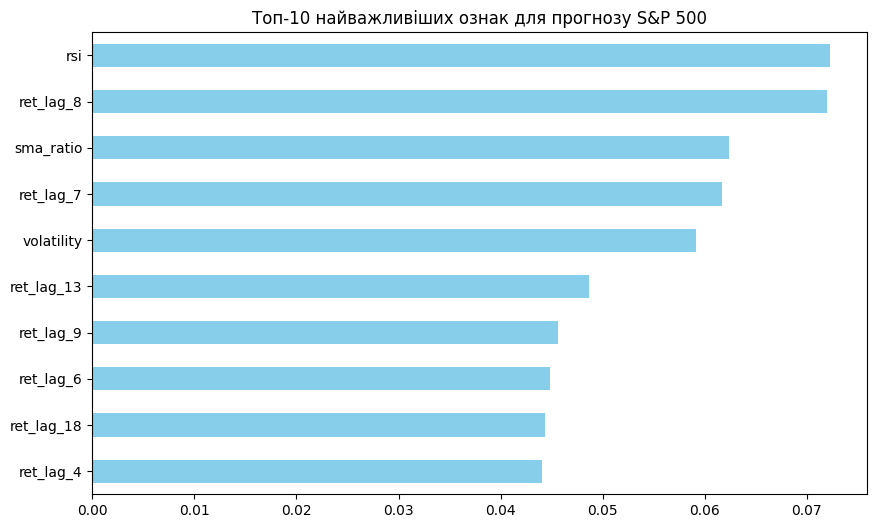

In [24]:
import matplotlib.pyplot as plt

# Отримуємо важливість ознак з XGBoost
importance = model_xgb_v2.feature_importances_
feat_importance = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 найважливіших ознак для прогнозу S&P 500')
plt.gca().invert_yaxis()
plt.show()

## 7. Фінальна зведена таблиця

In [ ]:
import numpy as np
import pandas as pd

print("--- ФІНАЛЬНА ЗВЕДЕНА ТАБЛИЦЯ (ФІНАНСИ, S&P 500) ---")

# Збираємо результати всіх моделей
results = []

# Функція для розрахунку метрик
def calc_finance_metrics(name, cls, true_prices, pred_prices, true_ret=None, pred_ret=None):
    mape = np.mean(np.abs((true_prices - pred_prices) / true_prices)) * 100
    row = {"Модель": name, "Клас": cls, "MAPE (%)": round(mape, 2)}
    if true_ret is not None and pred_ret is not None:
        da = np.mean(np.sign(true_ret) == np.sign(pred_ret)) * 100
        row["DA (%)"] = round(da, 2)
    else:
        row["DA (%)"] = "-"
    return row

# Baselines
results.append(calc_finance_metrics("Naive (t-1)", "Baseline", test_data['price'].values, test_data['naive_pred'].values))
results.append(calc_finance_metrics("S. Naive (t-5)", "Baseline", test_data['price'].values, test_data['s_naive_pred'].values))

# Statistics
for model_name, p in preds_stats.items():
    results.append(calc_finance_metrics(model_name, "Classic Statistics", test_data['price'].values, np.array(p)))

# ML/DL on prices (Stage 1)
results.append(calc_finance_metrics("XGBoost", "Traditional ML", y_test, xgb_p.flatten()))
results.append(calc_finance_metrics("SVR", "Traditional ML", y_test, svr_p.flatten()))
results.append(calc_finance_metrics("MLP", "Deep Learning", y_test, mlp_p.flatten()))
results.append(calc_finance_metrics("LSTM", "Deep Learning", y_test, lstm_p.flatten()))
results.append(calc_finance_metrics("1D-CNN", "Deep Learning", y_test, cnn_p.flatten()))

# Stage 2 (з індикаторами, на прибутках)
results.append(calc_finance_metrics("XGBoost v2", "ML (Opt.)", actual_prices_en, 
    last_prices_en * np.exp(xgb_ret_v2), y_test_en, xgb_ret_v2))
results.append(calc_finance_metrics("SVR v2", "ML (Opt.)", actual_prices_en, 
    last_prices_en * np.exp(svr_ret_v2), y_test_en, svr_ret_v2))
results.append(calc_finance_metrics("MLP v2", "DL (Opt.)", actual_prices_en, 
    last_prices_en * np.exp(mlp_ret_v2), y_test_en, mlp_ret_v2))
results.append(calc_finance_metrics("LSTM v2", "DL (Opt.)", actual_prices_en, 
    last_prices_en * np.exp(pred_ret_v2), y_test_en, pred_ret_v2))
results.append(calc_finance_metrics("1D-CNN v2", "DL (Opt.)", actual_prices_en, 
    last_prices_en * np.exp(cnn_ret_v2), y_test_en, cnn_ret_v2))

# Сортуємо за MAPE
results_df = pd.DataFrame(results).sort_values(by="MAPE (%)").reset_index(drop=True)
results_df.index = results_df.index + 1
print(results_df.to_string())